# Lab 2 — Hidden Layer Perceptron

Lab 1 showed that a single sigmoid node cannot learn XOR: it can only draw one
straight decision line, and XOR needs two. This lab adds a hidden layer —
`2 inputs -> 4 hidden (sigmoid) -> 1 output (sigmoid)` — and shows that this
extra layer is enough for the network to learn XOR.


In [1]:
import random
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from neural_network.activations import ACTIVATIONS
from neural_network.hyperparameters import random_weights, zero_bias
from neural_network.layer import Layer
from neural_network.network import Network
import trainer.trainer as trainer_module
from trainer.reporter import Reporter
from trainer.trainer import Trainer
from visualizer import GateVisualizer, TrainingVisualizer

from data import XOR_INPUTS, XOR_TARGETS

## Building a hidden-layer network

The hidden layer's 4 nodes each get to draw their own line through the input
space; the output node then combines those 4 lines into a single non-linear
boundary — enough to separate `{(0,1), (1,0)}` from `{(0,0), (1,1)}`.

XOR's plateau in Lab 1 took only 500 epochs to show; getting this deeper network
to actually converge needs more epochs, so `MAX_EPOCHS` is raised for this run.

In [2]:
random.seed(1)

hidden_layer = Layer.build(
    input_size=2, output_size=4,
    weight=random_weights(input_size=2, output_size=4), bias=zero_bias(4),
    activation_function=ACTIVATIONS.SIGMOID.function,
    activation_derivative=ACTIVATIONS.SIGMOID.derivative,
)
output_layer = Layer.build(
    input_size=4, output_size=1,
    weight=random_weights(input_size=4, output_size=1), bias=zero_bias(1),
    activation_function=ACTIVATIONS.SIGMOID.function,
    activation_derivative=ACTIVATIONS.SIGMOID.derivative,
)
xor_network = Network(hidden_layer, output_layer)

trainer_module.MAX_EPOCHS = 5000
trainer_module.REPORT_INTERVAL = 500

xor_trainer = Trainer(xor_network)
xor_trainer.train(XOR_INPUTS, XOR_TARGETS)

Epoch: 500/5000 | Error: 0.1750 | Accuracy: 75.00%
Epoch: 1000/5000 | Error: 0.0029 | Accuracy: 100.00%
Epoch: 1500/5000 | Error: 0.0011 | Accuracy: 100.00%
Epoch: 2000/5000 | Error: 0.0007 | Accuracy: 100.00%
Epoch: 2500/5000 | Error: 0.0005 | Accuracy: 100.00%
Epoch: 3000/5000 | Error: 0.0004 | Accuracy: 100.00%
Epoch: 3500/5000 | Error: 0.0003 | Accuracy: 100.00%
Epoch: 4000/5000 | Error: 0.0002 | Accuracy: 100.00%
Epoch: 4500/5000 | Error: 0.0002 | Accuracy: 100.00%
Epoch: 5000/5000 | Error: 0.0002 | Accuracy: 100.00%
Reached maximum epochs without meeting the error threshold.

Final Epoch:
Epoch: 5000/5000 | Error: 0.0002 | Accuracy: 100.00%


In [3]:
Reporter.report(xor_network, XOR_INPUTS, XOR_TARGETS)


Layer 0 weights:
[[-2.5085, -2.6182], [-6.6569, -6.7176], [-4.1557, -4.1779], [-2.9423, -2.9417]]
Layer 0 bias:
[-0.4038, 2.7822, 6.1536, 4.2756]

Layer 1 weights:
[[-2.0587, -10.6662, 7.5395, 4.6655]]
Layer 1 bias:
[-5.6520]

Inputs: [0.0000, 0.0000] | Target: [0.0000] | Prediction: [0.0122]
Inputs: [0.0000, 1.0000] | Target: [1.0000] | Prediction: [0.9874]
Inputs: [1.0000, 0.0000] | Target: [1.0000] | Prediction: [0.9873]
Inputs: [1.0000, 1.0000] | Target: [0.0000] | Prediction: [0.0160]

Accuracy: 100.00% (4/4 correct)


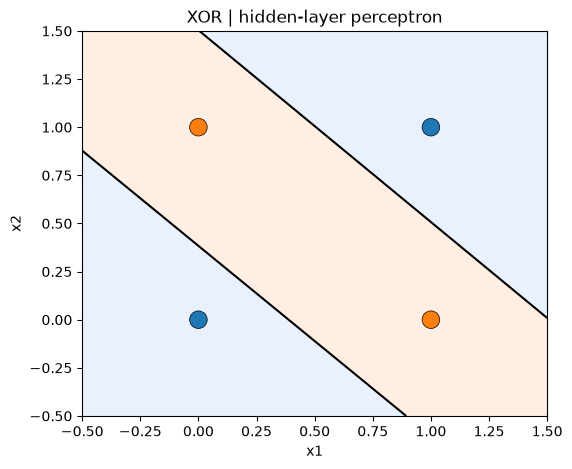

<Axes: title={'center': 'XOR | hidden-layer perceptron'}, xlabel='x1', ylabel='x2'>

In [4]:
GateVisualizer().plot(xor_network, XOR_INPUTS, XOR_TARGETS, title="XOR | hidden-layer perceptron")

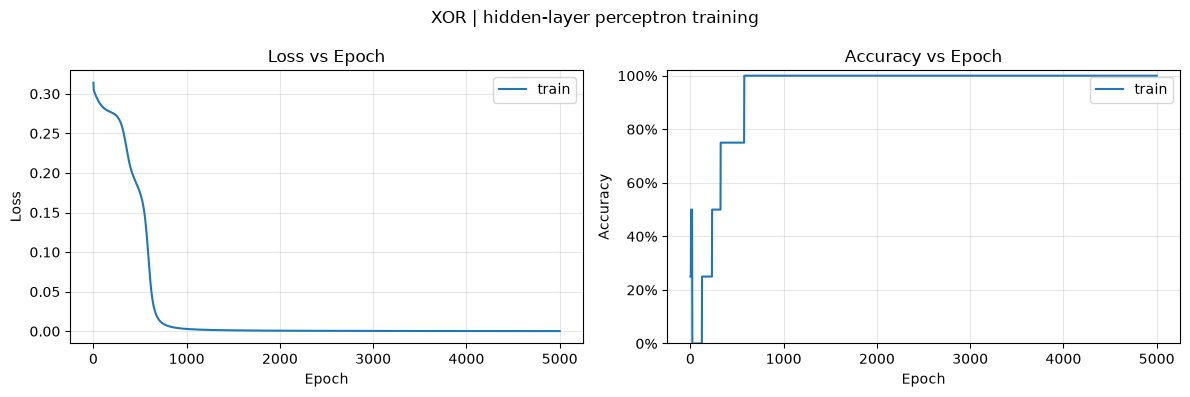

In [5]:
TrainingVisualizer().plot(xor_trainer, title="XOR | hidden-layer perceptron training")